# Netflix Dataset Cleaning & Preprocessing

This notebook focuses on cleaning and preprocessing the Netflix dataset before performing Exploratory Data Analysis (EDA).

## Import Required Libraries

The following libraries are used for:
- Data manipulation
- Data visualization
- Numerical operations

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

The Netflix dataset is loaded using pandas for preprocessing and analysis.

In [6]:
df = pd.read_csv("../data/raw/netflix_titles.csv")

## Dataset Information

Checking:
- Number of rows and columns
- Column names
- Datatypes
- General dataset information

In [7]:
df.shape

(8807, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [9]:
df.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

## Datatype Conversion

The `date_added` column is converted into datetime format for easier date analysis.

In [10]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [11]:
df["date_added"].isnull().sum()

np.int64(98)

## Standardizing Categorical Variables

Extra spaces and inconsistent text formatting are removed from categorical columns.

In [12]:
df["type"] = df["type"].str.strip()
df["country"] = df["country"].str.strip()
df["rating"] = df["rating"].str.strip()

In [ ]:
df["type"] = df["type"].str.title() 

## Duplicate Value Check

Duplicate rows are identified and removed to improve dataset quality.

In [14]:
df.duplicated().sum()

np.int64(0)

## Missing Value Handling

Missing values are handled using:
- Replacement with "Unknown"
- Replacement with mode values
- Filling missing date values

In [ ]:
df.isnull().sum()  

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### Director Column

Missing director names are replaced with "Unknown".

In [16]:
df["director"] = df["director"].fillna("Unknown")

### Cast Column

Missing cast values are replaced with "Not Available".

In [17]:
df["cast"] = df["cast"].fillna("Not Available")

### Country Column

Missing country values are replaced using the most frequent country (mode).

In [18]:

df["country"] = df["country"].fillna(df["country"].mode()[0])

### Rating Column

Missing rating values are replaced using the most frequent rating (mode).

In [19]:
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])



Checking whether missing values were successfully handled.

In [20]:

df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [21]:
df.describe()

,date_added,release_year
count,8709,8807.000000
mean,2019-05-23 01:45:29.452290,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-20 00:00:00,2013.000000
50%,2019-07-12 00:00:00,2017.000000
75%,2020-08-26 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


## Outlier Detection

Outliers are detected using:
- IQR Method
- Boxplot Visualization

In [22]:
Q1 = df["release_year"].quantile(0.25)
Q3 = df["release_year"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("lower:",lower)
print("upper:",upper)

outliers = df[(df["release_year"] < lower) | (df["release_year"] > upper)]

print(outliers)

lower: 2004.0
upper: 2028.0
     show_id   type              title          director  \
7         s8  Movie            Sankofa      Haile Gerima   
22       s23  Movie    Avvai Shanmughi    K.S. Ravikumar   
24       s25  Movie              Jeans        S. Shankar   
26       s27  Movie     Minsara Kanavu       Rajiv Menon   
41       s42  Movie               Jaws  Steven Spielberg   
...      ...    ...                ...               ...   
8764   s8765  Movie         Wyatt Earp   Lawrence Kasdan   
8766   s8767  Movie                XXx         Rob Cohen   
8768   s8769  Movie  Y Tu Mamá También    Alfonso Cuarón   
8770   s8771  Movie            Yaadein      Subhash Ghai   
8792   s8793  Movie        Young Tiger            Mu Chu   

                                                   cast  \
7     Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
22    Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...   
24    Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...   
26    Arvind Sw

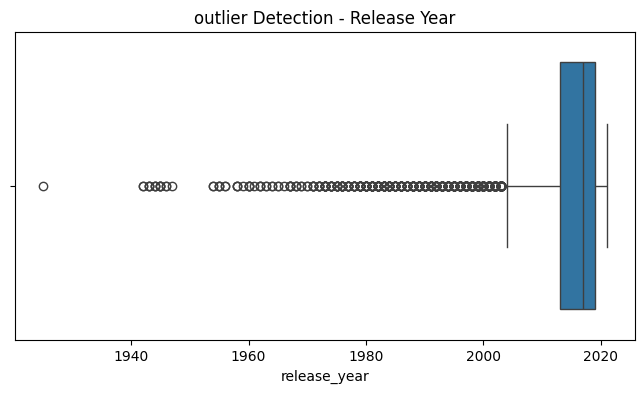

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["release_year"])
plt.title("outlier Detection - Release Year")
plt.show()

### Distribution of Release Year

Histogram is used to understand the distribution of release years in the dataset.

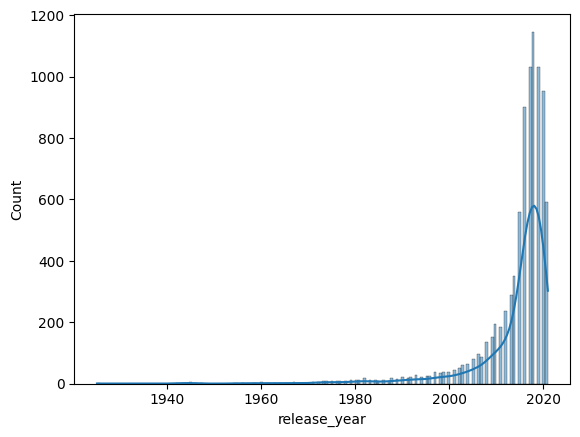

In [24]:
sns.histplot(df["release_year"], kde=True)
plt.show()

In [25]:
df.to_csv("cleaned_day2.csv", index=False)

In [26]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8709 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   str           
 9   duration      8804 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.8 KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Not Available,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Conclusion

The Netflix dataset was successfully cleaned and preprocessed by:
- Fixing datatypes
- Handling missing values
- Standardizing categorical variables
- Removing duplicates
- Detecting outliers

The cleaned dataset is now ready for Exploratory Data Analysis (EDA).

In [27]:
df.to_csv("cleaned_day2.csv", index=False)